# Laboratorio 16: Regresión logística con Iris

**Asignatura:** Analítica de Datos  
**Docente:** Luis Miguel Gómez Meneses  
**Universidad Cooperativa de Colombia**

## Objetivo

Entrenar un modelo que estime la probabilidad de que una flor sea
setosa utilizando el ancho de su sépalo.

## 1. Preparación de los datos

- **Entrada:** ancho del sépalo, en centímetros.
- **Clase 1:** setosa.
- **Clase 0:** no setosa; incluye versicolor y virginica.

Trabajaremos con las mismas 150 flores del laboratorio anterior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [2]:
iris = load_iris(as_frame=True)
df = iris.data[["sepal width (cm)"]].copy()
df.columns = ["ancho_sepalo"]
df["especie"] = iris.target.map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})
df["es_setosa"] = (df["especie"] == "setosa").astype(int)
display(df.head())
print("Cantidad de flores por clase:")
print(df["es_setosa"].value_counts().sort_index())

,ancho_sepalo,especie,es_setosa
0,3.5,setosa,1
1,3.0,setosa,1
2,3.2,setosa,1
3,3.1,setosa,1
4,3.6,setosa,1


Cantidad de flores por clase:
es_setosa
0    100
1     50
Name: count, dtype: int64


### Pregunta de análisis
¿Por qué este problema es de clasificación binaria si el dataset
contiene tres especies? Indica cuántas flores tiene cada clase.

## 2. Separación de datos y entrenamiento

Definimos:

- **X:** ancho del sépalo.
- **y:** clase binaria (`es_setosa`).

Separaremos las flores en:

- **80 % para entrenamiento:** el modelo aprende con estas flores.
- **20 % para prueba:** evaluaremos sus predicciones con estas flores.

Usaremos una separación estratificada para conservar la proporción
de setosa y no setosa en ambos conjuntos.

Después entrenaremos la regresión logística únicamente con
los datos de entrenamiento.

In [3]:
X = df[["ancho_sepalo"]]
y = df["es_setosa"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)
print("Flores de entrenamiento:", len(X_train))
print("Flores de prueba:", len(X_test))
print("Modelo entrenado.")

Flores de entrenamiento: 120
Flores de prueba: 30
Modelo entrenado.


### Pregunta de análisis

¿Por qué debemos evaluar el modelo con flores diferentes de las
que utilizamos para entrenarlo?

## 3. Predicciones sobre las flores de prueba

Obtendremos la probabilidad estimada de que cada flor sea setosa.

Aplicaremos un umbral de 0,5:

- Probabilidad ≥ 0,5: predecimos setosa (1).
- Probabilidad < 0,5: predecimos no setosa (0).

Compararemos las predicciones con las clases reales.

In [5]:
prob_setosa = modelo.predict_proba(X_test)[:, 1]
y_pred = (prob_setosa >= 0.5).astype(int)
comparacion = X_test.copy()
comparacion["clase_real"] = y_test
comparacion["probabilidad_setosa"] = prob_setosa
comparacion["clase_predicha"] = y_pred
comparacion["acierto"] = (
    comparacion["clase_real"] == comparacion["clase_predicha"]
)
comparacion.head(10).round(3)

,ancho_sepalo,clase_real,probabilidad_setosa,clase_predicha,acierto
137,3.1,0,0.316,0,True
27,3.5,1,0.622,1,True
136,3.4,0,0.545,1,False
132,2.8,0,0.152,0,True
71,2.8,0,0.152,0,True
70,3.2,0,0.389,0,True
134,2.6,0,0.087,0,True
51,3.2,0,0.389,0,True
47,3.2,1,0.389,0,False
124,3.3,0,0.466,0,True


## 4. Evaluación del modelo

Utilizaremos las 30 flores del conjunto de prueba.

La matriz de confusión mostrará los aciertos y errores.
Mantendremos setosa (1) como primera clase, igual que en la diapositiva.

Calcularemos:

- **Exactitud:** proporción total de aciertos.
- **Precisión:** de las flores predichas como setosa,
  qué proporción realmente lo es.
- **Recall:** de las setosa reales, qué proporción identificamos.
- **F1:** media armónica de precisión y recall.

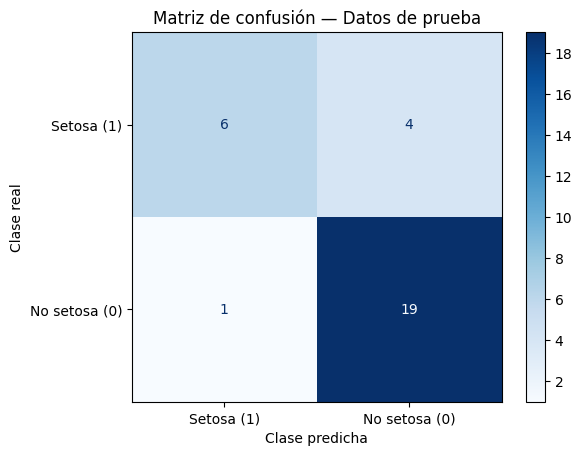

,Métrica,Valor
0,Exactitud,0.833
1,Precisión,0.857
2,Recall,0.600
3,F1,0.706


In [6]:
matriz = confusion_matrix(y_test, y_pred, labels=[1, 0])
grafico = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Setosa (1)", "No setosa (0)"]
)
grafico.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión — Datos de prueba")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()
metricas = pd.DataFrame({
    "Métrica": ["Exactitud", "Precisión", "Recall", "F1"],
    "Valor": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    ]
})
display(metricas.round(3))

## 5. Interpretación y conclusión

### Preguntas de análisis

1. Según la matriz de confusión, ¿cuántas flores setosa identificó
   correctamente el modelo y cuántas dejó sin identificar?

2. ¿Cuántas flores de otras especies clasificó erróneamente como setosa?

3. ¿Por qué la exactitud y el recall tienen valores diferentes?
   Explica qué evalúa cada métrica.

### Conclusión

Redacta un párrafo breve sobre qué tan bien permite el ancho
del sépalo identificar flores setosa.

Apoya tu conclusión en las métricas y los errores observados.
Explica por qué obtener una probabilidad alta no garantiza
que una predicción individual sea correcta.